# Lecture 6 — Class Exercise
## Part-to-Whole: Hierarchical Visualization

> **Push to:** `week06/lecture06_exercise.ipynb`

**Rules:**
1. Use `px` first, then customise with `update_traces` / `update_layout`
2. Colour encodes a meaningful category — not decoration
3. Insight title names the specific finding
4. Consider: would a bar chart be clearer? If yes, use the bar chart

---

In [8]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv(r"C:\Users\denni\Downloads\global_energy_mix.csv")

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}
df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))


Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


## Task 1 — Treemap: fossil fuel dependency by country

**What to build:** A treemap showing **fossil fuel TWh only**, broken down by Region → Country → Source (Coal / Oil / Natural Gas).

**Requirements:**
- Filter to fossil sources only before plotting
- Use `path=['Region', 'Country', 'Source']` for the hierarchy
- Colour encodes the fossil source type (Coal / Oil / Natural Gas) with a CVD-safe palette
- Show TWh values in labels — no percentages
- Grey out parent nodes (Region and Country level)
- Insight title naming which region or country is most fossil-dependent

> 💡 `df.loc[df['Source_Type'] == 'Fossil']`

In [9]:
df_fossil = df[df['Source'].isin(['Coal', 'Oil', 'Natural Gas'])]


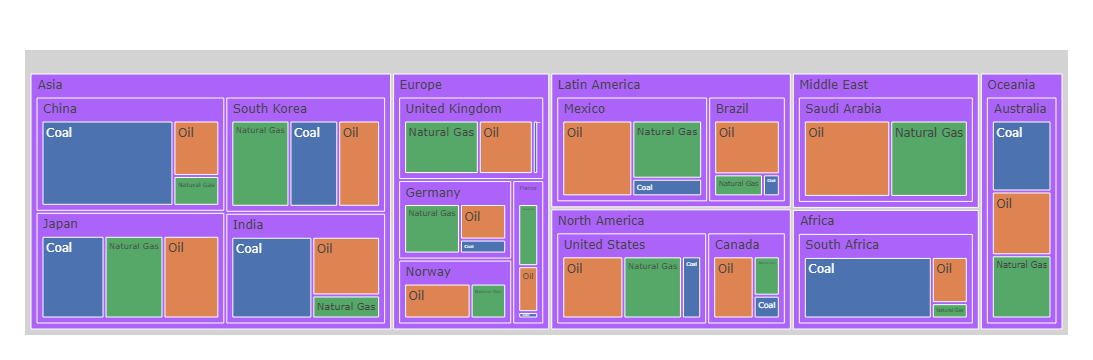

In [10]:
fig = px.treemap(
    df_fossil,
    path=['Region', 'Country', 'Source'],
    values='TWh',
    color='Source',
    color_discrete_map={
        'Coal': '#4C72B0',        # blue
        'Oil': '#DD8452',         # orange
        'Natural Gas': '#55A868'  # green
    }
)
fig.update_traces(root_color="lightgrey")  # grey out parent nodes
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.show()


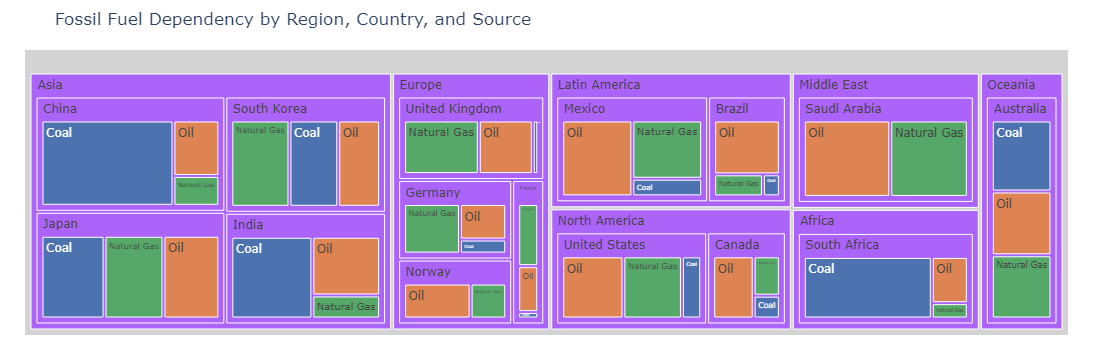

In [12]:
# Filter to fossil fuels
df_fossil = df[df['Source_Type'] == 'Fossil']

# Treemap
fig = px.treemap(
    df_fossil,
    path=['Region', 'Country', 'Source'],
    values='TWh',
    color='Source',
    color_discrete_map={
        'Coal': '#4C72B0',
        'Oil': '#DD8452',
        'Natural Gas': '#55A868'
    }
)

fig.update_traces(root_color="lightgrey")
fig.update_layout(
    title="Fossil Fuel Dependency by Region, Country, and Source",
    margin=dict(t=50, l=25, r=25, b=25)
)

fig.show()



## Task 2 — Sunburst: tipping behaviour by day and meal time

**What to build:** A sunburst chart using the built-in `tips` dataset showing how **total bill amount** is distributed across day → time → smoker status.

**Requirements:**
- Load tips with `px.data.tips()`
- Aggregate **total bill** (sum of `total_bill`) per group — not count
- Hierarchy: `path=['day', 'time', 'smoker']`
- Colour encodes smoker status with a CVD-safe blue/orange palette
- Grey out parent nodes (day and time level)
- Use `percent parent` for text labels
- Insight title describing where the most spending happens

> 💡 `tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()`

In [13]:
# Load built‑in dataset
tips = px.data.tips()

# Aggregate total bill per group
df_sunburst = (
    tips.groupby(['day', 'time', 'smoker'])['total_bill']
    .sum()
    .reset_index()
)


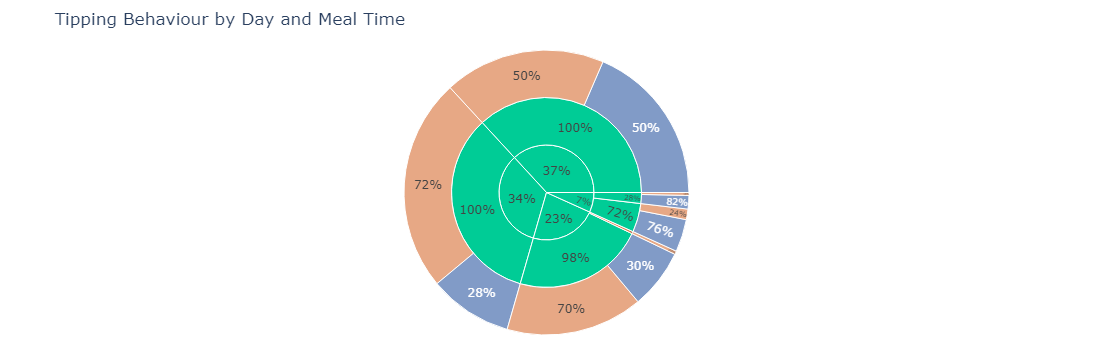

In [18]:
fig = px.sunburst(
    df_sunburst,
    path=['day', 'time', 'smoker'],
    values='total_bill',
    color='smoker',
    color_discrete_map={
        'Yes': '#4C72B0',   # blue
        'No':  '#DD8452'    # orange
    },
    branchvalues='total'   # ensures correct parent sizing
)

fig.update_traces(
    textinfo='percent parent',
    root_color='lightgrey'
)

fig.update_layout(
    title="Tipping Behaviour by Day and Meal Time",
    margin=dict(t=50, l=25, r=25, b=25)
)

fig.show()


In [19]:
insight = (
    df_sunburst.groupby(['day', 'time'])['total_bill']
    .sum()
    .sort_values(ascending=False)
)
insight.head()


day   time  
Sat   Dinner    1778.40
Sun   Dinner    1627.16
Thur  Lunch     1077.55
Fri   Dinner     235.96
      Lunch       89.92
Name: total_bill, dtype: float64

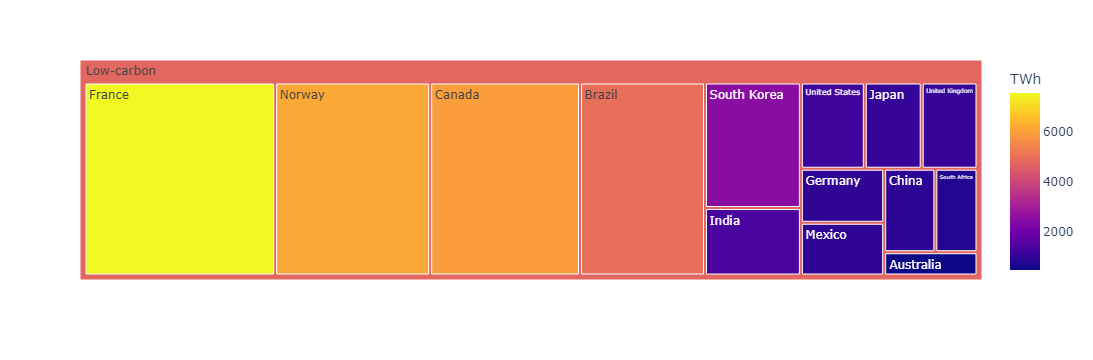

In [21]:
df_low = (
    df[df['Source_Type'] == 'Low-carbon']
    .groupby('Country')['TWh']
    .sum()
    .reset_index()
)

df_low['All'] = 'Low-carbon'

fig = px.treemap(
    df_low,
    path=['All', 'Country'],
    values='TWh',
    color='TWh'
)

fig.show()



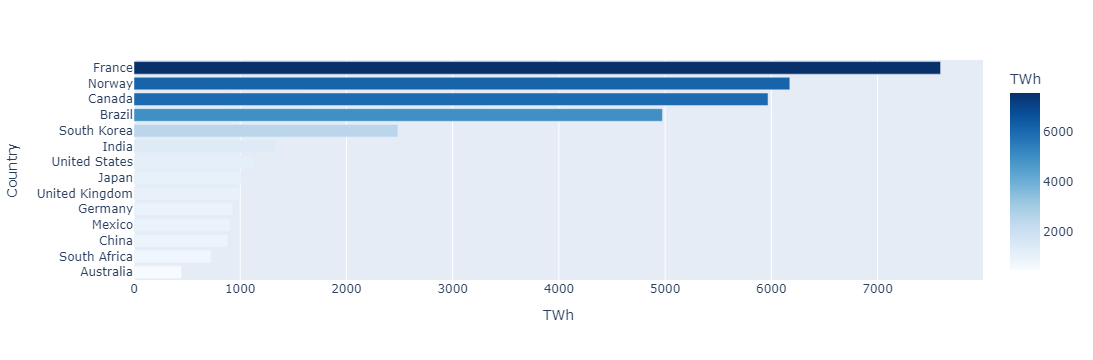

In [22]:
fig = px.bar(
    df_low.sort_values('TWh'),
    x='TWh',
    y='Country',
    orientation='h',
    color='TWh',
    color_continuous_scale='Blues'
)

fig.show()
